#23CO315 - Piyusha Supe
**NLP Practical 5**

Morphology is the study of the way words are built up from smaller meaning bearing units.
Study and understand the concepts of morphology by the use of add delete table

In [2]:
import pandas as pd

# Sample words
words = [
    "playing", "played", "plays",
    "running", "runner",
    "happiness", "unhappy",
    "cats", "boxes"
]

# Common suffixes
suffixes = ["ing", "ed", "s", "er", "ness"]

results = []

for word in words:
    base = word

    for suf in suffixes:
        if word.endswith(suf):
            base = word[:-len(suf)]  # delete suffix

            results.append({
                "Original Word": word,
                "Operation": "DELETE",
                "Removed": suf,
                "Base Form": base
            })

            # Add back transformation
            results.append({
                "Original Word": base,
                "Operation": "ADD",
                "Added": suf,
                "New Word": base + suf
            })

# Convert to DataFrame
df = pd.DataFrame(results)

df

,Original Word,Operation,Removed,Base Form,Added,New Word
0,playing,DELETE,ing,play,NaN,NaN
1,play,ADD,NaN,NaN,ing,playing
2,played,DELETE,ed,play,NaN,NaN
3,play,ADD,NaN,NaN,ed,played
4,plays,DELETE,s,play,NaN,NaN
5,play,ADD,NaN,NaN,s,plays
6,running,DELETE,ing,runn,NaN,NaN
7,runn,ADD,NaN,NaN,ing,running
8,runner,DELETE,er,runn,NaN,NaN
9,runn,ADD,NaN,NaN,er,runner


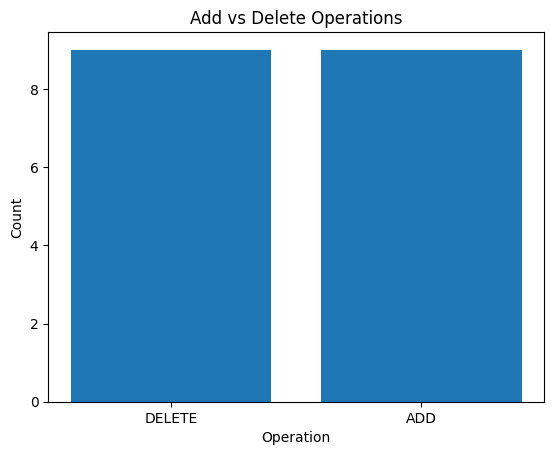

In [3]:
import matplotlib.pyplot as plt

counts = df['Operation'].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)
plt.title("Add vs Delete Operations")
plt.xlabel("Operation")
plt.ylabel("Count")
plt.show()

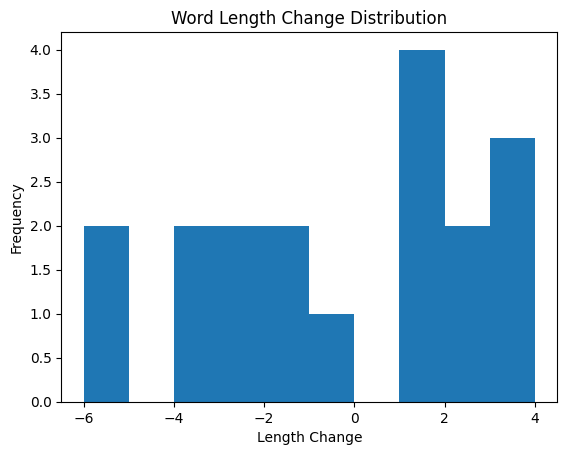

In [4]:
df['Length Change'] = df.apply(
    lambda x: len(str(x.get("New Word", x.get("Base Form")))) - len(x['Original Word']),
    axis=1
)

plt.figure()
plt.hist(df['Length Change'], bins=10)
plt.title("Word Length Change Distribution")
plt.xlabel("Length Change")
plt.ylabel("Frequency")
plt.show()

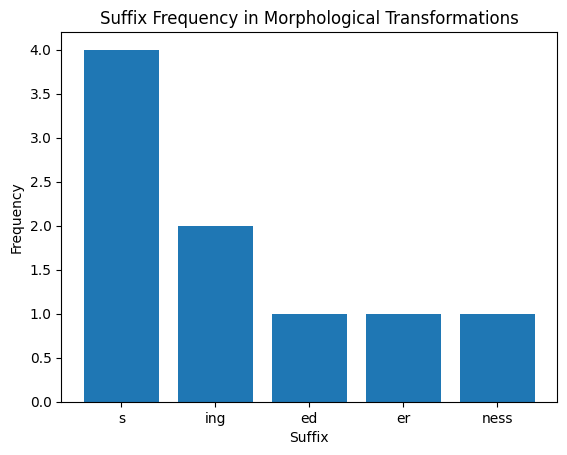

In [5]:
# Extract suffixes used
suffix_used = []

for _, row in df.iterrows():
    if row['Operation'] == 'DELETE':
        suffix_used.append(row['Removed'])

# Count frequency
suffix_counts = pd.Series(suffix_used).value_counts()

# Plot
import matplotlib.pyplot as plt

plt.figure()
plt.bar(suffix_counts.index, suffix_counts.values)
plt.title("Suffix Frequency in Morphological Transformations")
plt.xlabel("Suffix")
plt.ylabel("Frequency")
plt.show()